# Week 6 – Naïve Bayes: my extra work
COS30018 Lab 6. The provided `Naive_Bayes.ipynb` trains a `GaussianNB` on the weather/temperature/play toy data. Here I:

* **A.** redo the **spam example from the lab sheet** by hand ("Dear Friend" → normal or spam?)
* **B.** check I get the exact same numbers with sklearn's `MultinomialNB`
* **C.** look at the **zero-probability problem** (p(Lunch|Spam) = 0) and fix it with Laplace smoothing
* **D.** work out the weather example by hand and compare `GaussianNB` with `CategoricalNB`
* **E.** try Naïve Bayes on a real dataset (wine) with a train/test split + confusion matrix

In [1]:
from fractions import Fraction as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)
plt.rcParams["figure.dpi"] = 110

## A. Spam example from the lab sheet, by hand
12 emails: 8 normal, 4 spam. Word counts (from the sheet's histograms):

| word | normal | spam |
|---|---|---|
| Dear | 8 | 2 |
| Friend | 5 | 1 |
| Lunch | 3 | 0 |
| Money | 1 | 4 |
| **total** | **17** | **7** |

In [2]:
normal = {"Dear": 8, "Friend": 5, "Lunch": 3, "Money": 1}
spam   = {"Dear": 2, "Friend": 1, "Lunch": 0, "Money": 4}
prior = {"normal": F(8, 12), "spam": F(4, 12)}

def likelihoods(counts, alpha=0):
    total = sum(counts.values()) + alpha * len(counts)
    return {w: F(c + alpha, total) for w, c in counts.items()}

pN, pS = likelihoods(normal), likelihoods(spam)
table = pd.DataFrame({"p(word | Normal)": {w: f"{v} = {float(v):.2f}" for w, v in pN.items()},
                      "p(word | Spam)":   {w: f"{v} = {float(v):.2f}" for w, v in pS.items()}})
table

,p(word | Normal),p(word | Spam)
Dear,8/17 = 0.47,2/7 = 0.29
Friend,5/17 = 0.29,1/7 = 0.14
Lunch,3/17 = 0.18,0 = 0.00
Money,1/17 = 0.06,4/7 = 0.57


In [3]:
def score(message, prior_c, lik):
    s = prior_c
    for word in message.split():
        s *= lik[word]
    return s

msg = "Dear Friend"
sN = score(msg, prior["normal"], pN)
sS = score(msg, prior["spam"], pS)
print(f"score(N) = 8/12 * 8/17 * 5/17 = {float(sN):.4f}")
print(f"score(S) = 4/12 * 2/7  * 1/7  = {float(sS):.4f}")
print("prediction:", "NORMAL" if sN > sS else "SPAM")
print(f"\n(normalising the scores -> P(normal | '{msg}') = {float(sN / (sN + sS)):.3f})")

score(N) = 8/12 * 8/17 * 5/17 = 0.0923
score(S) = 4/12 * 2/7  * 1/7  = 0.0136
prediction: NORMAL

(normalising the scores -> P(normal | 'Dear Friend') = 0.871)


Same as the lab sheet: **0.09 > 0.01 → normal email**. The scores are only *proportional* to the posterior because we skip dividing by p(x) – but dividing both by their sum gives the actual probability (0.87).

## B. Same thing with sklearn's `MultinomialNB`
sklearn needs actual emails (rows of word counts), not totals, so I made up 12 emails whose counts add up to the table above. `alpha` ≈ 0 turns smoothing off so it should match my hand calculation.

In [4]:
from sklearn.naive_bayes import MultinomialNB

words = ["Dear", "Friend", "Lunch", "Money"]
normal_emails = [[1, 1, 0, 0]] * 5 + [[1, 0, 1, 0]] * 2 + [[1, 0, 1, 1]]      # 8 normal emails
spam_emails   = [[1, 0, 0, 1], [1, 0, 0, 1], [0, 1, 0, 1], [0, 0, 0, 1]]      # 4 spam emails
X = np.array(normal_emails + spam_emails)
y = np.array(["normal"] * 8 + ["spam"] * 4)
print("word totals  normal:", X[y == "normal"].sum(0), "| spam:", X[y == "spam"].sum(0))

nb = MultinomialNB(alpha=1e-10, force_alpha=True).fit(X, y)
print("\nlearned p(word | class):")
print(pd.DataFrame(np.exp(nb.feature_log_prob_).round(3), index=nb.classes_, columns=words))

dear_friend = [[1, 1, 0, 0]]
print("\nP(class | 'Dear Friend'):", {str(k): round(float(v), 3) for k, v in zip(nb.classes_, nb.predict_proba(dear_friend)[0])})
print("prediction:", nb.predict(dear_friend)[0])

word totals  normal: [8 5 3 1] | spam: [2 1 0 4]

learned p(word | class):
         Dear  Friend  Lunch  Money
normal  0.471   0.294  0.176  0.059
spam    0.286   0.143  0.000  0.571

P(class | 'Dear Friend'): {'normal': 0.871, 'spam': 0.129}
prediction: normal


✅ Identical: p(Dear|N) = 0.47, p(Money|S) = 0.57 … and P(normal | Dear Friend) = 0.871.

## C. The zero-probability problem
What about **"Lunch Money Money Money Money"**? Looks very spammy (4× Money!) but p(Lunch | Spam) = 0/7 = 0, so the whole spam score becomes 0 no matter what else is in the message.

Fix = **Laplace (add-one) smoothing**: add α = 1 to every word count before computing the probabilities, so nothing is ever exactly 0. (This is the `alpha` parameter in sklearn.)

In [5]:
msg2 = "Lunch Money Money Money Money"
rows = []
for alpha in [0, 1]:
    lN, lS = likelihoods(normal, alpha), likelihoods(spam, alpha)
    a, b = score(msg2, prior["normal"], lN), score(msg2, prior["spam"], lS)
    rows.append({"smoothing": f"alpha = {alpha}", "score(N)": float(a), "score(S)": float(b),
                 "prediction": "NORMAL" if a > b else "SPAM"})
res = pd.DataFrame(rows).set_index("smoothing")
print(res)

print("\nsklearn alpha=1 :", MultinomialNB(alpha=1).fit(X, y).predict([[0, 0, 1, 4]])[0])
print("sklearn alpha~0 :", MultinomialNB(alpha=1e-10, force_alpha=True).fit(X, y).predict([[0, 0, 1, 4]])[0])

           score(N)  score(S) prediction
smoothing                               
alpha = 0  0.000001  0.000000     NORMAL
alpha = 1  0.000010  0.001294       SPAM

sklearn alpha=1 : spam
sklearn alpha~0 : normal


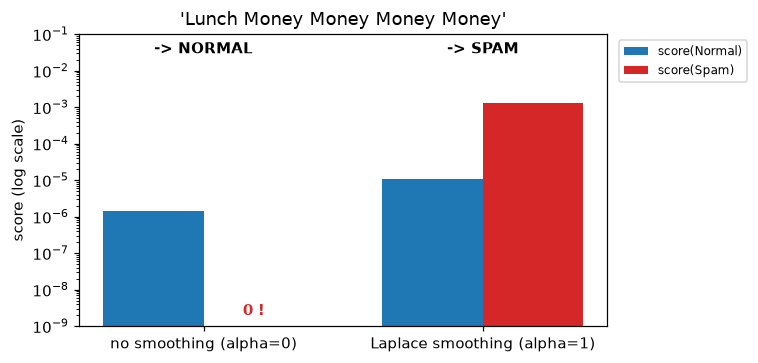

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
xpos = np.arange(2)
eps = 1e-9   # so a score of exactly 0 can still be drawn on a log axis
ax.bar(xpos - 0.18, res["score(N)"] + eps, width=0.36, label="score(Normal)", color="tab:blue")
ax.bar(xpos + 0.18, res["score(S)"] + eps, width=0.36, label="score(Spam)", color="tab:red")
ax.set_yscale("log"); ax.set_xticks(xpos, ["no smoothing (alpha=0)", "Laplace smoothing (alpha=1)"])
ax.set_ylabel("score (log scale)")
ax.set_title("'Lunch Money Money Money Money'")
ax.text(0.18, 2e-9, "0 !", ha="center", color="tab:red", fontweight="bold")
for i, p in enumerate(res["prediction"]):
    ax.text(i, 3e-2, f"-> {p}", ha="center", fontweight="bold")
ax.set_ylim(1e-9, 1e-1)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8); plt.tight_layout()
plt.savefig("figures/6_1_spam_smoothing.png", dpi=150)
plt.show()

Without smoothing the obvious spam is called **normal** (spam score = 0). With α = 1 it's correctly **spam**. So `alpha` really matters – sklearn uses α = 1 by default for this reason.

## D. The weather / temperature / play data from `Naive_Bayes.ipynb`
Encoded the same way as the provided notebook (LabelEncoder sorts alphabetically):
weather: Overcast=0, Rainy=1, Sunny=2 · temp: Cool=0, Hot=1, Mild=2 · play: No=0, Yes=1

In [7]:
weather = ['Sunny','Sunny','Overcast','Rainy','Rainy','Rainy','Overcast','Sunny','Sunny','Rainy','Sunny','Overcast','Overcast','Rainy']
temp    = ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild']
play    = ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
df = pd.DataFrame({"weather": weather, "temp": temp, "play": play})
print(pd.crosstab(df.weather, df.play), "\n")
print(pd.crosstab(df.temp, df.play))

play      No  Yes
weather          
Overcast   0    4
Rainy      2    3
Sunny      3    2 

play  No  Yes
temp         
Cool   1    3
Hot    2    2
Mild   2    4


By hand for the notebook's test case **(Overcast, Mild)** – counting from the tables above:

In [8]:
n_yes, n_no = (df.play == "Yes").sum(), (df.play == "No").sum()
def p(col, val, cls):
    sub = df[df.play == cls]
    return F(int((sub[col] == val).sum()), len(sub))

s_yes = F(int(n_yes), len(df)) * p("weather", "Overcast", "Yes") * p("temp", "Mild", "Yes")
s_no  = F(int(n_no),  len(df)) * p("weather", "Overcast", "No")  * p("temp", "Mild", "No")
print(f"score(Yes) = 9/14 * {p('weather','Overcast','Yes')} * {p('temp','Mild','Yes')} = {float(s_yes):.3f}")
print(f"score(No)  = 5/14 * {p('weather','Overcast','No')} * {p('temp','Mild','No')} = {float(s_no):.3f}")
print("-> play =", "Yes" if s_yes > s_no else "No", " (same as the notebook's 'Predicted Value: [1]')")

score(Yes) = 9/14 * 4/9 * 4/9 = 0.127
score(No)  = 5/14 * 0 * 2/5 = 0.000
-> play = Yes  (same as the notebook's 'Predicted Value: [1]')


`GaussianNB` (used in the provided notebook) assumes each feature is a **continuous normal distribution**, so it treats "Overcast=0, Rainy=1, Sunny=2" as numbers on a line – a bit weird for categories. sklearn has `CategoricalNB` which does exactly the counting I did by hand. Comparing both on all 9 combinations:

In [9]:
from sklearn import preprocessing
from sklearn.naive_bayes import GaussianNB, CategoricalNB

le_w, le_t, le_p = preprocessing.LabelEncoder(), preprocessing.LabelEncoder(), preprocessing.LabelEncoder()
Xw = np.column_stack([le_w.fit_transform(weather), le_t.fit_transform(temp)])
yp = le_p.fit_transform(play)

g = GaussianNB().fit(Xw, yp)
c = CategoricalNB(alpha=1).fit(Xw, yp)

rows = []
for w in le_w.classes_:
    for t in le_t.classes_:
        x = [[le_w.transform([w])[0], le_t.transform([t])[0]]]
        rows.append({"weather": w, "temp": t,
                     "GaussianNB": le_p.inverse_transform(g.predict(x))[0],
                     "P(yes) Gauss": round(g.predict_proba(x)[0][1], 2),
                     "CategoricalNB": le_p.inverse_transform(c.predict(x))[0],
                     "P(yes) Categ.": round(c.predict_proba(x)[0][1], 2)})
comp = pd.DataFrame(rows)
comp["agree?"] = np.where(comp.GaussianNB == comp.CategoricalNB, "yes", "NO")
comp

,weather,temp,GaussianNB,P(yes) Gauss,CategoricalNB,P(yes) Categ.,agree?
0,Overcast,Cool,Yes,0.99,Yes,0.89,yes
1,Overcast,Hot,Yes,0.99,Yes,0.80,yes
2,Overcast,Mild,Yes,0.99,Yes,0.87,yes
3,Rainy,Cool,Yes,0.76,Yes,0.68,yes
4,Rainy,Hot,Yes,0.67,Yes,0.52,yes
5,Rainy,Mild,Yes,0.67,Yes,0.64,yes
6,Sunny,Cool,No,0.39,Yes,0.55,NO
7,Sunny,Hot,No,0.29,No,0.37,yes
8,Sunny,Mild,No,0.30,No,0.50,yes


They agree on 8 of the 9 combinations but **not on Sunny + Cool** (Gaussian says No, Categorical says Yes with 0.55). The probabilities are quite different too – CategoricalNB's are the "real" counting probabilities (with α = 1 smoothing), GaussianNB's come from fitting bell curves to the 0/1/2 codes, which is why I'd use CategoricalNB for data like this.

## E. Naïve Bayes on a real dataset – wine (built into sklearn)
178 wines, 13 chemical measurements (continuous → `GaussianNB` actually makes sense here), 3 cultivars.

In [10]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

wine = load_wine()
Xtr, Xte, ytr, yte = train_test_split(wine.data, wine.target, test_size=0.3, random_state=42, stratify=wine.target)
gnb = GaussianNB().fit(Xtr, ytr)
pred = gnb.predict(Xte)
print(f"train accuracy: {accuracy_score(ytr, gnb.predict(Xtr)):.3f}")
print(f"test accuracy : {accuracy_score(yte, pred):.3f}  ({(pred == yte).sum()}/{len(yte)} correct)")

train accuracy: 0.968
test accuracy : 1.000  (54/54 correct)


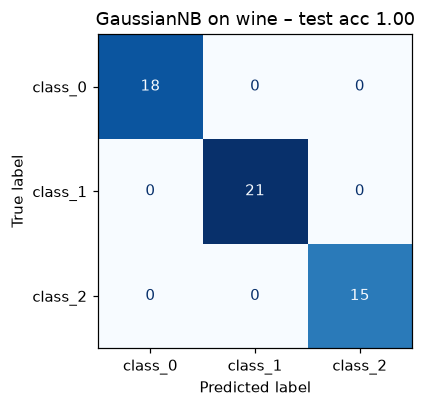

In [11]:
fig, ax = plt.subplots(figsize=(4.2, 3.8))
ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=wine.target_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"GaussianNB on wine – test acc {accuracy_score(yte, pred):.2f}")
plt.tight_layout(); plt.savefig("figures/6_2_wine_confusion_matrix.png", dpi=150); plt.show()

## Takeaways
* Naïve Bayes = prior × product of p(feature | class), pick the class with the bigger score. "Naïve" because it assumes the words/features are independent given the class (word order is ignored completely – "Dear Friend" = "Friend Dear").
* One zero count kills the whole product → always use smoothing (α).
* Pick the NB flavour that matches the features: `MultinomialNB` for counts, `CategoricalNB` for categories, `GaussianNB` for continuous numbers.
* It's super fast and still good on real data: on my wine split it got all 54 test wines right (and 96.8% on the training set – the test set is small, so that 100% is a bit lucky).